# 02 — Modelagem, avaliação e interpretação

Este notebook continua o `AnaliseExploratoria.ipynb`. Aqui refazemos a divisão dos dados e os três modelos (com os mesmos parâmetros e `random_state=42`) e depois:

1. Analisamos a correlação entre as medidas (T07)
2. Avaliamos os modelos no conjunto de teste (T12)
3. Repetimos a avaliação com validação cruzada
4. Vemos quais medidas mais pesam nas decisões: importância e SHAP (T13, T14)
5. Discutimos o uso prático do modelo (T15)

Nas métricas, a classe "positiva" é **M (maligno)**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, make_scorer)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

df = pd.read_csv("../data/data.csv").drop(columns=['id', 'Unnamed: 32'])
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

## T07 — Análise de correlação

In [2]:
corr = X.corr()
pares = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
             .stack().dropna().rename('correlação').reset_index()
             .rename(columns={'level_0': 'feature A', 'level_1': 'feature B'}))
pares['|r|'] = pares['correlação'].abs()
top_pares = pares.sort_values('|r|', ascending=False).head(15).drop(columns='|r|')
print(f"Pares com |r| > 0,9: {(pares['|r|'] > 0.9).sum()} de {len(pares)}")
top_pares.round(3).reset_index(drop=True)

Pares com |r| > 0,9: 21 de 435


,feature A,feature B,correlação
0,radius_mean,perimeter_mean,0.998
1,radius_worst,perimeter_worst,0.994
2,radius_mean,area_mean,0.987
3,perimeter_mean,area_mean,0.987
4,radius_worst,area_worst,0.984
5,perimeter_worst,area_worst,0.978
6,radius_se,perimeter_se,0.973
7,perimeter_mean,perimeter_worst,0.970
8,radius_mean,radius_worst,0.970
9,perimeter_mean,radius_worst,0.969


In [3]:
y_bin = (y == 'M').astype(int)
corr_alvo = X.corrwith(y_bin).sort_values(key=np.abs, ascending=False)
corr_alvo.head(10).round(3)

concave points_worst    0.794
perimeter_worst         0.783
concave points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
area_worst              0.734
radius_mean             0.730
area_mean               0.709
concavity_mean          0.696
concavity_worst         0.660
dtype: float64

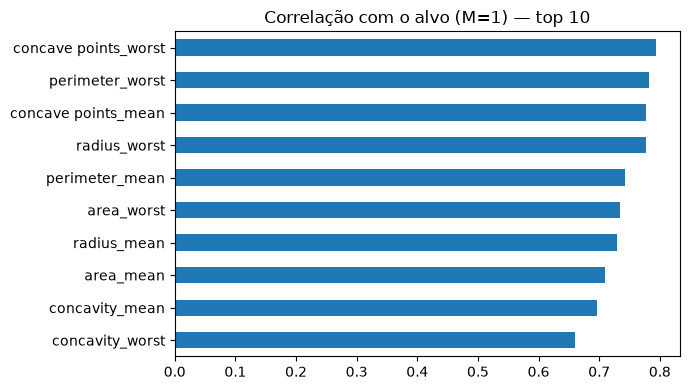

In [4]:
plt.figure(figsize=(7, 4))
corr_alvo.sort_values().tail(10).plot.barh(title="Correlação com o alvo (M=1) — top 10")
plt.tight_layout()
plt.savefig("../reports/figures/correlacao_alvo.png", dpi=150)
plt.show()

**Conclusão T07 — correlação**

Correlação mede o quanto duas medidas andam juntas. Vai de -1 a 1: perto de 1, as duas sobem juntas.

- Existem 21 pares de medidas com correlação acima de 0,9 (de 435 pares possíveis). Quase todos são `radius` (raio), `perimeter` (perímetro) e `area` (área): elas medem o tamanho do núcleo, então é natural que cresçam juntas. Exemplo: `radius_mean` e `perimeter_mean` têm 0,998.
- As medidas mais ligadas ao diagnóstico são `concave points_worst`, `perimeter_worst`, `concave points_mean` e `radius_worst`, todas com correlação de cerca de 0,78 com ser maligno. São as mesmas que aparecem como mais importantes no SHAP, mais abaixo, o que reforça o resultado.
- Como o "tamanho" aparece repetido em várias colunas, os coeficientes da Regressão Logística ficam difíceis de interpretar e a importância se divide entre essas colunas. Isso não atrapalha a previsão, só a interpretação. Uma melhoria futura seria tirar as medidas repetidas, mas não fizemos isso aqui.

## Split e modelos (mesmos parâmetros dos T08–T11)

In [5]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15/0.85, stratify=y_temp, random_state=42)
print(len(X_train), len(X_val), len(X_test))

def make_model(classifier):
    pre = ColumnTransformer(transformers=[('num', Pipeline(steps=[('scaler', StandardScaler())]), list(X.columns))])
    return Pipeline(steps=[('preprocessor', pre), ('classifier', classifier)])

modelos = {
    'Regressão Logística': make_model(LogisticRegression(random_state=42)),
    'Random Forest': make_model(RandomForestClassifier(random_state=42)),
    'KNN': make_model(KNeighborsClassifier()),
}
for m in modelos.values():
    m.fit(X_train, y_train)

397 86 86


## Conferência com os resultados do T09–T11

In [6]:
esperado = {'Regressão Logística': 0.977, 'Random Forest': 0.965, 'KNN': 0.977}
for nome, m in modelos.items():
    acc = accuracy_score(y_val, m.predict(X_val))
    assert round(acc, 3) == esperado[nome], (nome, acc)
    print(f"{nome:20s} acurácia (validação) = {acc:.3f}  OK")

Regressão Logística  acurácia (validação) = 0.977  OK
Random Forest        acurácia (validação) = 0.965  OK
KNN                  acurácia (validação) = 0.977  OK


## T12 — Avaliação no conjunto de teste

O conjunto de teste só é usado aqui, uma única vez, com os modelos treinados apenas no treino. Olhamos principalmente o **recall do maligno**: de todos os casos realmente malignos, quantos o modelo encontrou. O pior erro é o **falso negativo** (um caso maligno classificado como benigno).

In [7]:
linhas = []
matrizes = {}
for nome, m in modelos.items():
    pred = m.predict(X_test)
    linhas.append({
        'Modelo': nome,
        'Accuracy': accuracy_score(y_test, pred),
        'Recall (M)': recall_score(y_test, pred, pos_label='M'),
        'Precisão (M)': precision_score(y_test, pred, pos_label='M'),
        'F1 (M)': f1_score(y_test, pred, pos_label='M'),
    })
    matrizes[nome] = confusion_matrix(y_test, pred, labels=['B', 'M'])

resultados = pd.DataFrame(linhas).set_index('Modelo').round(3)
resultados

,Accuracy,Recall (M),Precisão (M),F1 (M)
Modelo,,,,
Regressão Logística,0.988,0.969,1.000,0.984
Random Forest,0.965,0.906,1.000,0.951
KNN,0.953,0.906,0.967,0.935


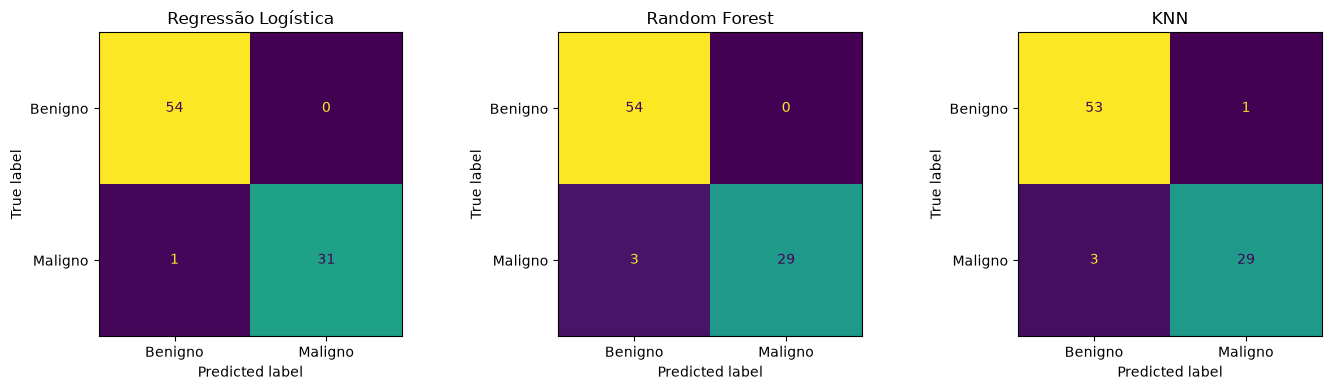

Regressão Logística  falsos negativos (M como B) = 1 | falsos positivos (B como M) = 0
Random Forest        falsos negativos (M como B) = 3 | falsos positivos (B como M) = 0
KNN                  falsos negativos (M como B) = 3 | falsos positivos (B como M) = 1


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (nome, cm) in zip(axes, matrizes.items()):
    ConfusionMatrixDisplay(cm, display_labels=['Benigno', 'Maligno']).plot(ax=ax, colorbar=False)
    ax.set_title(nome)
plt.tight_layout()
plt.savefig("../reports/figures/matrizes_confusao_teste.png", dpi=150)
plt.show()

for nome, cm in matrizes.items():
    tn, fp, fn, tp = cm.ravel()
    print(f"{nome:20s} falsos negativos (M como B) = {fn} | falsos positivos (B como M) = {fp}")

**Conclusão T12** (teste com 86 amostras, 32 malignas)

| Modelo | Accuracy | Recall (M) | Precisão (M) | F1 (M) |
|---|---|---|---|---|
| Regressão Logística | 0,988 | 0,969 | 1,000 | 0,984 |
| Random Forest | 0,965 | 0,906 | 1,000 | 0,951 |
| KNN | 0,953 | 0,906 | 0,967 | 0,935 |

- **Por que recall?** Um falso negativo deixa passar um tumor maligno, o que é mais grave do que um falso positivo (que só leva a um exame a mais). A acurácia sozinha não mostra isso: como cerca de 63% dos casos são benignos, ela pode parecer alta mesmo errando casos malignos.
- A Regressão Logística foi melhor em todas as métricas: errou só 1 caso maligno e nenhum falso positivo (benigno marcado como maligno). Random Forest e KNN erraram 3 casos malignos cada.
- **Cuidado:** o teste tem só 32 casos malignos, então cada erro muda o recall em cerca de 3 pontos. A diferença entre os modelos (1 a 3 erros) é pequena para tirar conclusões firmes. A validação cruzada, logo abaixo, ajuda a confirmar.
- O modelo serve de apoio à triagem; quem decide o diagnóstico é sempre o médico.

## Validação cruzada

No teste temos poucos casos malignos, então o resultado pode variar por sorte. Na validação cruzada os dados são divididos em 10 partes: o modelo é treinado com 9 e testado na parte que sobrou, repetindo 10 vezes. No final vemos a média e o desvio (quanto o resultado varia entre as partes). Usamos só treino + validação; o conjunto de teste não é usado aqui.

In [9]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = {'accuracy': 'accuracy', 'recall_M': 'recall', 'f1_M': 'f1'}
y_temp_bin = (y_temp == 'M').astype(int)   # M=1 para o scorer usar pos_label=1

linhas = []
for nome, m in modelos.items():
    r = cross_validate(m, X_temp, y_temp_bin, cv=cv, scoring=scoring)
    linhas.append({
        'Modelo': nome,
        'Accuracy': f"{r['test_accuracy'].mean():.3f} ± {r['test_accuracy'].std():.3f}",
        'Recall (M)': f"{r['test_recall_M'].mean():.3f} ± {r['test_recall_M'].std():.3f}",
        'F1 (M)': f"{r['test_f1_M'].mean():.3f} ± {r['test_f1_M'].std():.3f}",
    })
pd.DataFrame(linhas).set_index('Modelo')

,Accuracy,Recall (M),F1 (M)
Modelo,,,
Regressão Logística,0.973 ± 0.023,0.956 ± 0.042,0.963 ± 0.031
Random Forest,0.956 ± 0.024,0.928 ± 0.043,0.941 ± 0.031
KNN,0.965 ± 0.021,0.911 ± 0.044,0.950 ± 0.030


**Conclusão da validação cruzada**

| Modelo | Accuracy | Recall (M) | F1 (M) |
|---|---|---|---|
| Regressão Logística | 0,973 ± 0,023 | 0,956 ± 0,042 | 0,963 ± 0,031 |
| Random Forest | 0,956 ± 0,024 | 0,928 ± 0,043 | 0,941 ± 0,031 |
| KNN | 0,965 ± 0,021 | 0,911 ± 0,044 | 0,950 ± 0,030 |

- A Regressão Logística ficou na frente nas três métricas, como no teste. Isso dá mais confiança de que não foi sorte da divisão.
- Mas a variação do recall (cerca de 0,04) é parecida com a diferença entre os modelos (0,956 contra 0,928 do Random Forest). Então a vantagem existe, mas não é certa.
- O KNN teve o menor recall (0,911), o que é ruim para triagem, mesmo com acurácia parecida com a dos outros.

## T13 e T14 — Interpretabilidade

In [10]:
modelo_lr = modelos['Regressão Logística']
modelo_rf = modelos['Random Forest']

## T13 — Feature importance

### Random Forest: importância por impureza

Mostra o quanto cada medida ajudou as árvores a separar benigno de maligno durante o treino. Pode favorecer medidas parecidas entre si, por isso comparamos também com a importância por permutação.

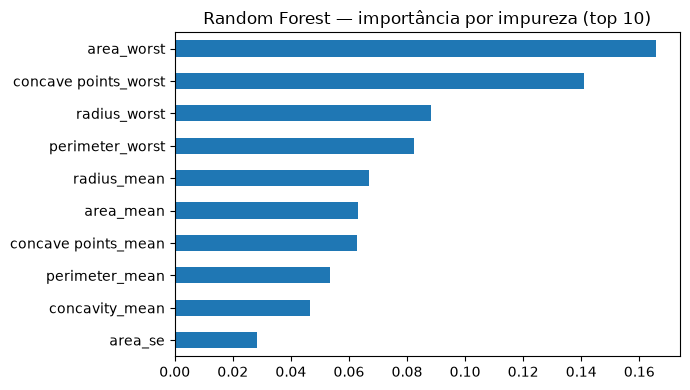

area_worst              0.166
concave points_worst    0.141
radius_worst            0.088
perimeter_worst         0.082
radius_mean             0.067
area_mean               0.063
concave points_mean     0.063
perimeter_mean          0.054
concavity_mean          0.047
area_se                 0.028
dtype: float64

In [11]:
imp_rf = pd.Series(modelo_rf.named_steps['classifier'].feature_importances_, index=X.columns).sort_values()
imp_rf.tail(10).plot.barh(figsize=(7, 4), title="Random Forest — importância por impureza (top 10)")
plt.tight_layout()
plt.savefig("../reports/figures/importancia_rf_impureza.png", dpi=150)
plt.show()
imp_rf.sort_values(ascending=False).head(10).round(3)

### Importância por permutação

Embaralha os valores de uma medida por vez e vê quanto o recall do maligno cai. Se cair muito, a medida era importante. Feito no conjunto de validação (o teste continua sem uso).

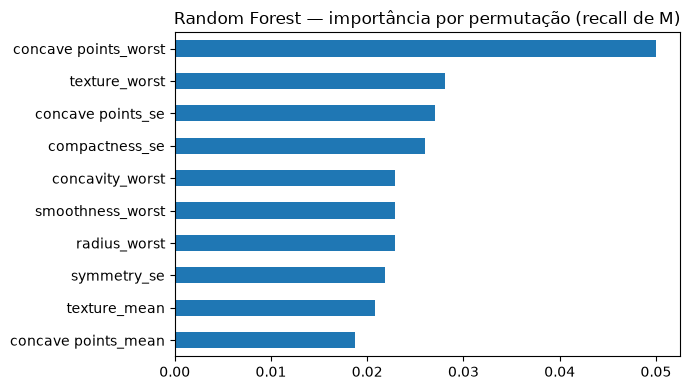

concave points_worst    0.0500
texture_worst           0.0281
concave points_se       0.0271
compactness_se          0.0260
concavity_worst         0.0229
smoothness_worst        0.0229
radius_worst            0.0229
symmetry_se             0.0219
texture_mean            0.0208
concave points_mean     0.0188
dtype: float64

In [12]:
scorer = make_scorer(recall_score, pos_label='M')
perm = permutation_importance(modelo_rf, X_val, y_val, scoring=scorer, n_repeats=30, random_state=42)
imp_perm = pd.Series(perm.importances_mean, index=X.columns).sort_values()
imp_perm.tail(10).plot.barh(figsize=(7, 4), title="Random Forest — importância por permutação (recall de M)")
plt.tight_layout()
plt.savefig("../reports/figures/importancia_rf_permutacao.png", dpi=150)
plt.show()
imp_perm.sort_values(ascending=False).head(10).round(4)

### Regressão Logística: coeficientes

O coeficiente é o peso que a regressão deu a cada medida (as medidas já estão padronizadas, então dá para comparar). Peso positivo aumenta a chance de maligno; peso negativo diminui.

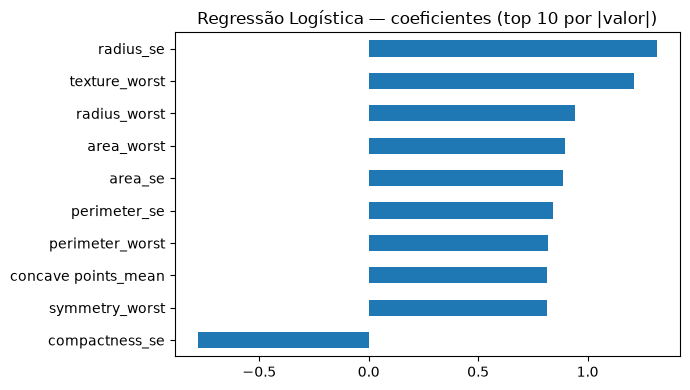

radius_se              1.317
texture_worst          1.214
radius_worst           0.943
area_worst             0.899
area_se                0.885
perimeter_se           0.844
perimeter_worst        0.820
concave points_mean    0.817
symmetry_worst         0.815
compactness_se        -0.781
dtype: float64

In [13]:
coef = pd.Series(modelo_lr.named_steps['classifier'].coef_[0], index=X.columns)
assert list(modelo_lr.named_steps['classifier'].classes_) == ['B', 'M']  # coef positivo => aumenta P(maligno)
top = coef.reindex(coef.abs().sort_values().index).tail(10)
top.plot.barh(figsize=(7, 4), title="Regressão Logística — coeficientes (top 10 por |valor|)")
plt.tight_layout()
plt.savefig("../reports/figures/coeficientes_lr.png", dpi=150)
plt.show()
top.sort_values(ascending=False).round(3)

## T14 — SHAP

O SHAP mostra, para cada paciente, quanto cada medida empurrou a previsão para "maligno" (direita) ou para "benigno" (esquerda). Cada ponto é um paciente do teste, e a cor é o valor da medida (vermelho = alto, azul = baixo). Usamos o SHAP só para explicar os modelos, não para escolher entre eles.

Background dataset has 397 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=397 when initializing the masker.
/var/folders/06/dzr69s010s5_0d45scy1610w0000gn/T/ipykernel_39914/33147728.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_lr.values, Xte_lr, show=False)


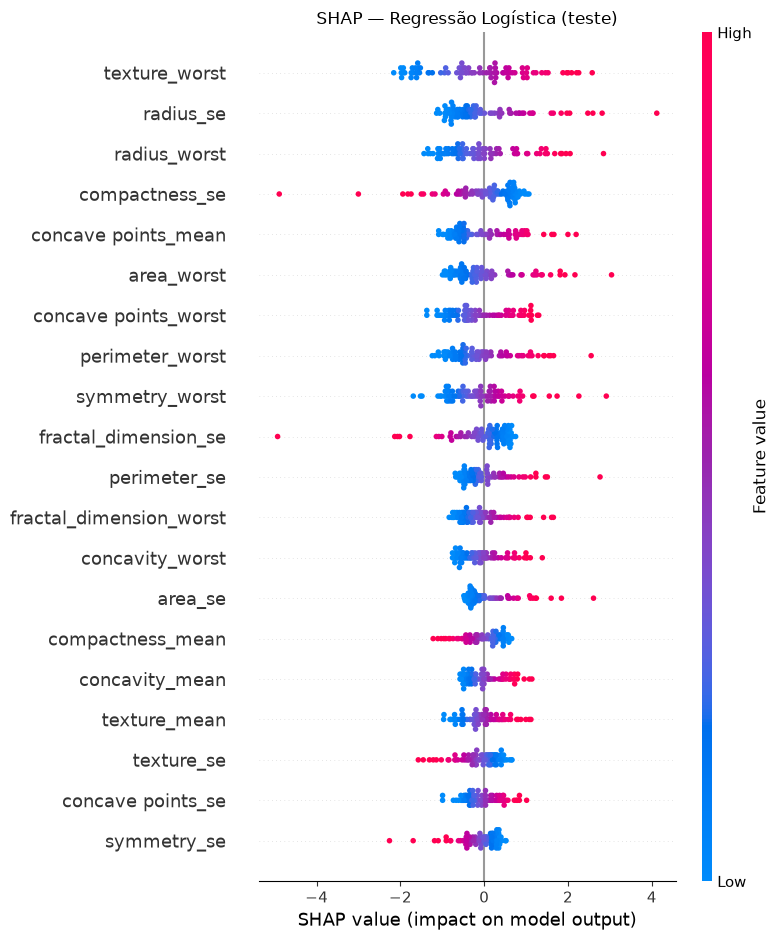

In [14]:
def dados_transformados(modelo, Xd):
    pre = modelo.named_steps['preprocessor']
    return pd.DataFrame(pre.transform(Xd), columns=X.columns, index=Xd.index)

# Regressão Logística (linear)
Xtr_lr = dados_transformados(modelo_lr, X_train)
Xte_lr = dados_transformados(modelo_lr, X_test)
expl_lr = shap.LinearExplainer(modelo_lr.named_steps['classifier'], Xtr_lr)
sv_lr = expl_lr(Xte_lr)

shap.summary_plot(sv_lr.values, Xte_lr, show=False)
plt.title("SHAP — Regressão Logística (teste)")
plt.tight_layout()
plt.savefig("../reports/figures/shap_summary_lr.png", dpi=150)
plt.show()

/var/folders/06/dzr69s010s5_0d45scy1610w0000gn/T/ipykernel_39914/2068157790.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(vals_rf, Xte_rf, show=False)


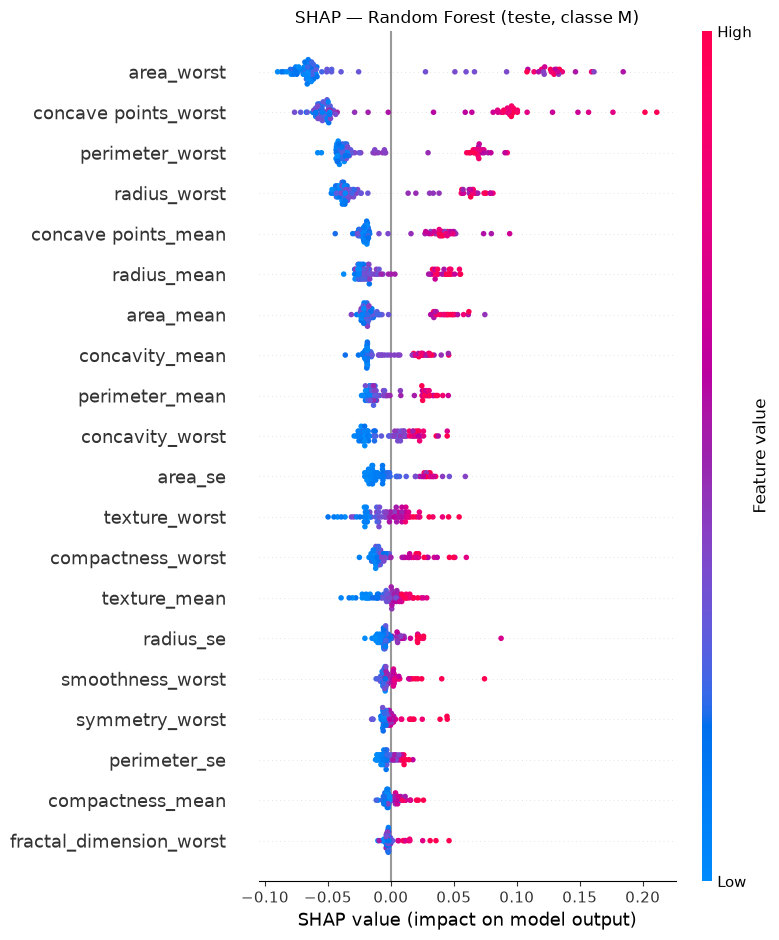

In [15]:
# Random Forest (árvores)
Xte_rf = dados_transformados(modelo_rf, X_test)
expl_rf = shap.TreeExplainer(modelo_rf.named_steps['classifier'])
sv_rf = expl_rf(Xte_rf)
idx_m = list(modelo_rf.named_steps['classifier'].classes_).index('M')
vals_rf = sv_rf.values[:, :, idx_m] if sv_rf.values.ndim == 3 else sv_rf.values

shap.summary_plot(vals_rf, Xte_rf, show=False)
plt.title("SHAP — Random Forest (teste, classe M)")
plt.tight_layout()
plt.savefig("../reports/figures/shap_summary_rf.png", dpi=150)
plt.show()

In [16]:
# Importância global média |SHAP| dos dois modelos
comp = pd.DataFrame({
    'LR': np.abs(sv_lr.values).mean(axis=0),
    'RF': np.abs(vals_rf).mean(axis=0),
}, index=X.columns)
comp['LR'] /= comp['LR'].sum(); comp['RF'] /= comp['RF'].sum()
comp.sort_values('RF', ascending=False).head(10).round(3)

,LR,RF
area_worst,0.051,0.167
concave points_worst,0.050,0.140
perimeter_worst,0.050,0.089
radius_worst,0.059,0.089
concave points_mean,0.052,0.061
radius_mean,0.017,0.053
area_mean,0.021,0.053
concavity_mean,0.030,0.041
perimeter_mean,0.017,0.038
concavity_worst,0.035,0.035


## Conclusões T13 e T14

- **Random Forest:** as medidas mais importantes são `area_worst`, `concave points_worst`, `perimeter_worst` e `radius_worst`, ou seja, tamanho e irregularidade do núcleo. No SHAP, valores altos dessas medidas empurram para maligno e valores baixos para benigno.
- **Medidas repetidas:** raio, perímetro e área medem quase a mesma coisa. Por isso, na importância por permutação, nenhuma delas se destaca muito: ao embaralhar uma, as outras "cobrem" a falta. É melhor ler essas medidas como um grupo ("tamanho do núcleo").
- **Regressão Logística:** os coeficientes parecem estranhos (por exemplo, `radius_se` no topo e `compactness_se` com peso negativo). Como as medidas se repetem, o modelo divide os pesos de um jeito instável. Ele prevê bem, mas não dá para interpretar cada peso isoladamente.
- **Cuidado com o SHAP:** ele explica o que o *modelo* aprendeu, não a causa da doença. A decisão continua sendo do médico.

## T15 — Discussão crítica de uso prático

**Papel do modelo.** O modelo é um apoio à triagem: ele indica quais casos merecem atenção primeiro. Não faz diagnóstico. O médico avalia junto com o histórico da paciente e outros exames, e tem a palavra final.

**Qual erro pesa mais.** No teste, a Regressão Logística errou 1 dos 32 casos malignos (recall 0,969) e não marcou nenhum benigno como maligno. Random Forest e KNN deixaram passar 3 casos malignos (recall 0,906). Um falso negativo atrasa a descoberta de um câncer, enquanto um falso positivo leva a um exame a mais. Por isso o recall do maligno é a métrica principal, e a Regressão Logística é a melhor escolha aqui.

**Interpretação.** O SHAP mostra que o modelo usa principalmente tamanho e irregularidade do núcleo (`area_worst`, `concave points_worst`, `perimeter_worst`), o que faz sentido e combina com a correlação com o diagnóstico. Isso ajuda o médico a conferir a lógica do modelo. Mas é só uma explicação do modelo, não prova o que causa a doença.

**Limitações.**
- Poucos dados: 569 casos, todos da mesma base (Breast Cancer Wisconsin). Não sabemos se funcionaria igual em outro hospital ou equipamento.
- Poucos casos malignos no teste (32), então os resultados variam bastante (cerca de ±0,04 no recall, na validação cruzada).
- Muitas medidas repetidas (T07): o modelo acerta bem aqui, mas casos mais difíceis ou raros podem ter resultado pior.
